# BioScope Certainty Dataset Pipeline

This notebook builds and explores the certain / uncertain sentence tables used for DistilBERT MLP probing.

Pipeline (same style as earlier MS504 / MS505 coursework notebooks):

1. Library Import
2. About the Dataset
3. Data Import
4. Data Exploration
5. Data Preprocessing
6. Data Visualisation

# Library Import

In [34]:
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import pandas as pd
from datasets import Dataset

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.facecolor"] = "white"

# About the Dataset

**Source.** [BioScope](https://rgai.inf.u-szeged.hu/node/105) (Vincze et al., 2008) is a public biomedical corpus with three parts:

| Part | File | Content |
|---|---|---|
| Abstract | `abstracts.xml` | biomedical abstract sentences |
| Paper | `full_papers.xml` | full-paper sentences |
| Medical text | `clinical_records_anon.xml` | clinical notes (anonymised) |

**Why this dataset.** The thesis probes whether DistilBERT MLP activations encode linguistic certainty. BioScope already annotates *speculation* (hedges) and *negation*, so we can derive binary certain / uncertain labels from a published resource.

**Labelling rule** (applied later in Data Preprocessing, speculation only):

| `label` | `label_name` | Rule |
|---|---|---|
| `1` | `certain` | no speculation cue in the sentence |
| `0` | `uncertain` | at least one speculation cue (e.g. *may*, *suggest*, *indicate that*) |

Negation is kept as `has_negation` but does **not** flip the class on its own.

**Important.** Clinical notes in BioScope are anonymised to `*` tokens. They still appear in the raw import. We explore that first, then drop them in **Data Preprocessing** as they are not pre-cleaned by the download.

**Final outputs under `dataset/`** (written after preprocessing):

| File | Content |
|---|---|
| `bioscope_certainty_full.csv` | usable abstract + paper sentences |
| `bioscope_certainty.csv` | balanced probing set |

Train / validation / test splitting is left for a later notebook step.

# Data Import

## Load raw BioScope

`datasets>=4` no longer runs Hub loading scripts, and `bigbio/bioscope` still only ships `bioscope.py`. The URL inside that script also has a broken TLS certificate. We therefore download the official zip from the corpus homepage and parse the XML locally (cached under `~/.cache/bioscope`).

This step loads **all three sources as-is**, including medical `*` rows. No filtering yet.

In [35]:
ZIP_URL = "https://rgai.inf.u-szeged.hu/sites/rgai.inf.u-szeged.hu/files/bioscope.zip"
CACHE = Path.home() / ".cache" / "bioscope"
SOURCES = {
    "Abstract": "abstracts.xml",
    "Paper": "full_papers.xml",
    "Medical text": "clinical_merger/clinical_records_anon.xml",
}


def _extract_entities(sentence, prefix):
    text = "".join(sentence.itertext())
    cues = {cue.attrib["ref"]: cue for cue in sentence.iter("cue")}
    entities = []
    for xcope in sentence.iter("xcope"):
        cue = cues.get(xcope.attrib["id"])
        if cue is None:  # e.g. X2.140.2 has no cue in the raw XML
            continue
        span = "".join(xcope.itertext())
        start = text.find(span)
        entities.append(
            {
                "id": f"{prefix}_{xcope.attrib['id']}",
                "type": cue.attrib.get("type", ""),
                "text": span,
                "start": start,
                "end": start + len(span) if start >= 0 else -1,
            }
        )
    return entities


def load_bioscope(subset="all"):
    """Load BioScope. subset is 'all', 'Abstract', 'Paper', or 'Medical text'."""
    CACHE.mkdir(parents=True, exist_ok=True)
    zip_path = CACHE / "bioscope.zip"
    data_dir = CACHE / "bioscope"
    if not zip_path.exists():
        urlretrieve(ZIP_URL, zip_path)
    if not (data_dir / "abstracts.xml").exists():
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(data_dir)

    wanted = SOURCES if subset == "all" else {subset: SOURCES[subset]}
    rows = []
    for document_type, relpath in wanted.items():
        prefix = document_type[0]
        for sentence in ET.parse(data_dir / relpath).getroot().iter("sentence"):
            sid = sentence.attrib["id"]
            rows.append(
                {
                    "document_id": f"{prefix}_{sid}",
                    "document_type": document_type,
                    "sentence_id": sid,
                    "text": "".join(sentence.itertext()),
                    "entities": _extract_entities(sentence, prefix),
                }
            )
    return Dataset.from_list(rows)


ds = load_bioscope()
ds

Dataset({
    features: ['document_id', 'document_type', 'sentence_id', 'text', 'entities'],
    num_rows: 20924
})

## Convert raw BioScope to a dataframe for exploration

Every sentence is flattened into `raw_df` **without dropping anything**. Speculation / negation flags are added only so we can inspect the corpus; final labels and cleaning come after exploration.

In [36]:
raw_rows = []
for row in ds:
    text = " ".join(row["text"].split())
    entities = row["entities"] or []
    has_speculation = any(e["type"] == "speculation" for e in entities)
    has_negation = any(e["type"] == "negation" for e in entities)
    raw_rows.append(
        {
            "document_id": row["document_id"],
            "document_type": row["document_type"],
            "sentence_id": row["sentence_id"],
            "text": text,
            "n_alpha": sum(ch.isalpha() for ch in text),
            "has_speculation": has_speculation,
            "has_negation": has_negation,
            "n_entities": len(entities),
        }
    )

raw_df = pd.DataFrame(raw_rows)
raw_df.insert(0, "id", range(1, len(raw_df) + 1))

print("raw_df shape (all sources, unfiltered):", raw_df.shape)
print(raw_df["document_type"].value_counts().to_string())
raw_df.head()

raw_df shape (all sources, unfiltered): (20924, 9)
document_type
Abstract        11871
Medical text     6383
Paper            2670


,id,document_id,document_type,sentence_id,text,n_alpha,has_speculation,has_negation,n_entities
0,1,A_S1.1,Abstract,S1.1,Induction of NF-KB during monocyte differentiation by HIV type 1 infection.,62,False,False,0
1,2,A_S1.2,Abstract,S1.2,The production of human immunodeficiency virus type 1 (HIV-1) progeny was followed in the U937 promonocytic cell lin...,176,False,False,0
2,3,A_S1.3,Abstract,S1.3,Electrophoretic mobility shift assays and Southwestern blotting experiments were used to detect the binding of cellu...,194,False,False,0
3,4,A_S1.4,Abstract,S1.4,"PMA treatment, and not retinoic acid treatment of the U937 cells acts in inducing NF-KB expression in the nuclei.",89,False,True,1
4,5,A_S1.5,Abstract,S1.5,"In nuclear extracts from monocytes or macrophages, induction of NF-KB occurred only if the cells were previously inf...",109,False,False,0


# Data Exploration

Explore the **raw** corpus first (`raw_df`), before any edits. Goals: we need to understand the following: 
* shape, 
* missing values, 
* document mix, 
* the reducted clinical information (*) 
* how speculation / negation are distributed.

## First look at the raw table

In [37]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20924 entries, 0 to 20923
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               20924 non-null  int64
 1   document_id      20924 non-null  str  
 2   document_type    20924 non-null  str  
 3   sentence_id      20924 non-null  str  
 4   text             20924 non-null  str  
 5   n_alpha          20924 non-null  int64
 6   has_speculation  20924 non-null  bool 
 7   has_negation     20924 non-null  bool 
 8   n_entities       20924 non-null  int64
dtypes: bool(2), int64(3), str(4)
memory usage: 3.9 MB


In [38]:
raw_df.isnull().sum()

id                 0
document_id        0
document_type      0
sentence_id        0
text               0
n_alpha            0
has_speculation    0
has_negation       0
n_entities         0
dtype: int64

No nullable records detected

In [39]:
print("duplicate rows:", int(raw_df.duplicated().sum()))
print("duplicate texts:", int(raw_df.duplicated(subset=["text"]).sum()))

duplicate rows: 0
duplicate texts: 5669


## Document types in the raw download

BioScope ships three sources. Counts below are **before** preprocessing.

document_type
Abstract        11871
Medical text     6383
Paper            2670
Name: count, dtype: int64

document_type
Abstract        0.567
Medical text    0.305
Paper           0.128
Name: proportion, dtype: float64

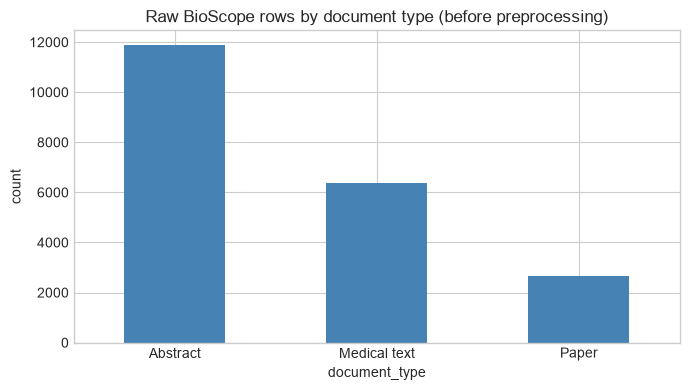

In [40]:
display(raw_df["document_type"].value_counts())
display(raw_df["document_type"].value_counts(normalize=True).round(3))

raw_df["document_type"].value_counts().plot(
    kind="bar", figsize=(7, 4), color="steelblue", rot=0
)
plt.title("Raw BioScope rows by document type (before preprocessing)")
plt.xlabel("document_type")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Medical text is anonymised to `*`

The clinical file still contains rows, but the publishers replaced every token with `*`. That is already in the download. Below  shows examples and how little alphabetic text remains.

In [ ]:
# Lets lock the medical rows column which is reduced to `*`
medical_df = raw_df.loc[raw_df["document_type"] == "Medical text"].copy()
print(f"Medical text rows: {len(medical_df)}")
print("n_alpha summary for medical rows:")
display(medical_df["n_alpha"].describe())

print("\nExamples of medical rows which is reduced to `*`:")
medical_df.head(5)

Medical text rows: 6383
n_alpha summary for medical rows:


count    6383.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: n_alpha, dtype: float64


Examples of medical rows which is reduced to `*`:
...


,id,document_id,document_type,sentence_id,text,n_alpha,has_speculation,has_negation,n_entities
20919,20920,M_S1954.4,Medical text,S1954.4,"* * * * * - * *, * * * * * * * * * * *.",0,False,True,1
20920,20921,M_S1954.5,Medical text,S1954.5,* * * *.,0,False,False,0
20921,20922,M_S1954.6,Medical text,S1954.6,*.,0,False,False,0
20922,20923,M_S1954.7,Medical text,S1954.7,"* * * * *, * * *.",0,False,True,1
20923,20924,M_S1954.8,Medical text,S1954.8,* * - * * * * *-* * - * *.,0,False,False,0


These medical rows cannot be used for DistilBERT probing: there is no readable sentence left. They must be removed in Data Preprocessing.

In [61]:
medical_df.tail(5)

,id,document_id,document_type,sentence_id,text,n_alpha,has_speculation,has_negation,n_entities
20919,20920,M_S1954.4,Medical text,S1954.4,"* * * * * - * *, * * * * * * * * * * *.",0,False,True,1
20920,20921,M_S1954.5,Medical text,S1954.5,* * * *.,0,False,False,0
20921,20922,M_S1954.6,Medical text,S1954.6,*.,0,False,False,0
20922,20923,M_S1954.7,Medical text,S1954.7,"* * * * *, * * *.",0,False,True,1
20923,20924,M_S1954.8,Medical text,S1954.8,* * - * * * * *-* * - * *.,0,False,False,0


## Speculation and negation in the raw corpus

BioScope already marks speculation and negation. This is not a label we invent, it is the annotation we will map to our labels **certain** / **uncertain** later.

In [64]:
display(raw_df["has_speculation"].value_counts())

display(raw_df["has_negation"].value_counts())

# Breaking it down by document type
pd.crosstab(raw_df["document_type"], raw_df["has_speculation"], margins=True)

has_speculation
False    17449
True      3475
Name: count, dtype: int64

has_negation
False    18123
True      2801
Name: count, dtype: int64

has_speculation,False,True,All
document_type,,,
Abstract,9770,2101,11871
Medical text,5528,855,6383
Paper,2151,519,2670
All,17449,3475,20924


## Example abstract / paper sentences

Readable text lives in Abstracts and Papers. A few examples with and without speculation:

In [ ]:
readable = raw_df.loc[raw_df["document_type"].isin(["Abstract", "Paper"])]

print("Example WITHOUT speculation (candidate certain)")
# Lets lock the readable rows with not speculation ~  False, THese are the candidates for the certain sentences
display(
    readable.loc[~readable["has_speculation"], ["id", "document_type", "text", "has_speculation", "has_negation"]].head(5)
)

print("Example WITH speculation (candidate uncertain)")
display(
    readable.loc[readable["has_speculation"], ["id", "document_type", "text", "has_speculation", "has_negation"]].head(5)
)

Example WITHOUT speculation (candidate certain)


,id,document_type,text,has_speculation,has_negation
0,1,Abstract,Induction of NF-KB during monocyte differentiation by HIV type 1 infection.,False,False
1,2,Abstract,The production of human immunodeficiency virus type 1 (HIV-1) progeny was followed in the U937 promonocytic cell lin...,False,False
2,3,Abstract,Electrophoretic mobility shift assays and Southwestern blotting experiments were used to detect the binding of cellu...,False,False
3,4,Abstract,"PMA treatment, and not retinoic acid treatment of the U937 cells acts in inducing NF-KB expression in the nuclei.",False,True
4,5,Abstract,"In nuclear extracts from monocytes or macrophages, induction of NF-KB occurred only if the cells were previously inf...",False,False


Example WITH speculation (candidate uncertain)


,id,document_type,text,has_speculation,has_negation
5,6,Abstract,"When U937 cells were infected with HIV-1, no induction of NF-KB factor was detected, whereas high level of progeny v...",True,True
6,7,Abstract,"These results indicate that in monocytic cell lineage, HIV-1 could mimic some differentiation/activation stimuli all...",True,False
9,10,Abstract,"Tandem copies of this 67-bp MnlI-AluI fragment, when fused to the chloramphenicol acetyltransferase gene driven by t...",True,True
10,11,Abstract,"Footprinting analysis revealed that the identical sequence CCGAAACTGAAAAGG, designated E6, was protected by nuclear ...",True,False
12,13,Abstract,"In agreement with the results of gel retardation assays, tandem copies of the E6 motif stimulated transcription in A...",True,True


## Character length in readable sources

Quick length check on abstracts + papers only (medical `*` rows are near-zero length and would distort the picture).

In [44]:
readable = raw_df.loc[raw_df["document_type"].isin(["Abstract", "Paper"])].copy()
readable["text_len"] = readable["text"].str.len()
readable.groupby("has_speculation")["text_len"].describe().T

has_speculation,False,True
count,11921.000000,2620.000000
mean,151.039510,186.622901
std,68.802831,70.036311
min,2.000000,37.000000
25%,104.000000,137.000000
50%,141.000000,180.000000
75%,187.000000,227.000000
max,899.000000,674.000000


### Checking dataset with n_alpha < 20

In [80]:
# records with n_alpha < 20
short_df = raw_df[raw_df["n_alpha"] < 20]
short_df[["id", "document_type", "text", "n_alpha"]]

,id,document_type,text,n_alpha
2438,2439,Abstract,BACKGROUND .,10
2441,2442,Abstract,METHODS .,7
2445,2446,Abstract,RESULTS .,7
2448,2449,Abstract,CONCLUSIONS .,11
2480,2481,Abstract,"13,800 ± 300).",0
...,...,...,...,...
20919,20920,Medical text,"* * * * * - * *, * * * * * * * * * * *.",0
20920,20921,Medical text,* * * *.,0
20921,20922,Medical text,*.,0
20922,20923,Medical text,"* * * * *, * * *.",0


These texts of headings , reduced text can not be used for our probing task we will need to drop these records in the data preprocessing steps.

In [78]:
# in the range of 20 to 25
large_df = raw_df[raw_df["n_alpha"].isin(range(20, 25))]
large_df[["id", "document_type", "text", "n_alpha"]].head(5)



,id,document_type,text,n_alpha
532,533,Abstract,the Kd was unchanged (9.3 ± 2.6 vs 9.2 ± 2.4 nM).,21
1384,1385,Abstract,"Sentman et al. , 1991; Strasser et al. , 1991).",23
1948,1949,Abstract,(ABSTRACT TRUNCATED AT 250 WORDS),24
2231,2232,Abstract,Hypertension in pregnancy.,23
2672,2673,Abstract,(ABSTRACT TRUNCATED AT 250 WORDS),24


# Data Preprocessing

Exploration showed that medical rows are anonymised to `*` and that speculation cues can define certain / uncertain labels. This section **edits** the data for the thesis pipeline.

Steps:

1. Drop `Medical text` (no readable tokens)
2. Drop very short alphabetic fragments
3. Map BioScope speculation → binary `certain` / `uncertain`
4. Build class views and a balanced probing table
5. Save CSVs under `dataset/`

## 1. Drop medical `*` rows and short fragments

**What.** Remove every row with `document_type == "Medical text"`, then remove sentences with fewer than `MIN_ALPHA` alphabetic characters.

**Why.** Clinical notes were anonymised by BioScope to `*` only — DistilBERT cannot encode meaning from them. Short fragments (headings, punctuation-only lines) are also not useful sentence probes.

**Note.** We are not stripping `*` characters from otherwise good text. We drop whole unusable rows.

In [ ]:
# Hand picked the minimum number of alphabetic characters to keep we can increase this number if we want to keep more of the sentences
MIN_ALPHA = 20

n_before = len(raw_df)
n_medical = int((raw_df["document_type"] == "Medical text").sum())

clean_base = raw_df.loc[raw_df["document_type"] != "Medical text"].copy()
n_after_medical = len(clean_base)

short_mask = clean_base["n_alpha"] < MIN_ALPHA
n_short = int(short_mask.sum())
clean_base = clean_base.loc[~short_mask].reset_index(drop=True)

print(f"raw rows:                         {n_before}")
print(f"dropped Medical text:             {n_medical}")
print(f"remaining after medical drop:     {n_after_medical}")
print(f"dropped short fragments (<{MIN_ALPHA} letters): {n_short}")
print(f"usable rows for labelling:        {len(clean_base)}")
print()
print(clean_base["document_type"].value_counts().to_string())

raw rows:                         20924
dropped Medical text:             6383
remaining after medical drop:     14541
dropped short fragments (<20 letters): 108
usable rows for labelling:        14433

document_type
Abstract    11859
Paper        2574


## 2. Create certain / uncertain labels

BioScope does not ship a `certain` / `uncertain` column. It ships speculation annotations. We map them as follows:

- `has_speculation == True` → `uncertain` (`label = 0`)
- `has_speculation == False` → `certain` (`label = 1`)

Negation stays as `has_negation` and does not redefine the class.

In [ ]:
# Rebuild cue strings from the HuggingFace Dataset for the kept sentence ids
entity_by_key = {}
for row in ds:
    if row["document_type"] == "Medical text":
        # Skip medical rows as they are anonymised to `*`
        continue
    key = (row["document_id"], row["sentence_id"])
    entities = row["entities"] or []
    spec_cues = sorted(
        {
            e["text"].strip()
            for e in entities
            if e["type"] == "speculation" and e["text"].strip()
        }
    )
    entity_by_key[key] = "; ".join(spec_cues)

df = clean_base.copy()
# Map speculation to certain / uncertain
df["label"] = df["has_speculation"].map({True: 0, False: 1})
df["label_name"] = df["has_speculation"].map({True: "uncertain", False: "certain"})
# Build speculation cues
df["speculation_cues"] = [
    entity_by_key.get((doc, sid), "")
    for doc, sid in zip(df["document_id"], df["sentence_id"])
]
df["text_len"] = df["text"].str.len()
df = df.drop(columns=["n_alpha", "n_entities", "has_speculation"]).reset_index(drop=True)
df["id"] = range(1, len(df) + 1)

print(df["label_name"].value_counts().to_string())
print()
print(pd.crosstab(df["document_type"], df["label_name"]))
df.head()

label_name
certain      11813
uncertain     2620

label_name     certain  uncertain
document_type                    
Abstract          9758       2101
Paper             2055        519


,id,document_id,document_type,sentence_id,text,has_negation,label,label_name,speculation_cues,text_len
0,1,A_S1.1,Abstract,S1.1,Induction of NF-KB during monocyte differentiation by HIV type 1 infection.,False,1,certain,,75
1,2,A_S1.2,Abstract,S1.2,The production of human immunodeficiency virus type 1 (HIV-1) progeny was followed in the U937 promonocytic cell lin...,False,1,certain,,218
2,3,A_S1.3,Abstract,S1.3,Electrophoretic mobility shift assays and Southwestern blotting experiments were used to detect the binding of cellu...,False,1,certain,,227
3,4,A_S1.4,Abstract,S1.4,"PMA treatment, and not retinoic acid treatment of the U937 cells acts in inducing NF-KB expression in the nuclei.",True,1,certain,,113
4,5,A_S1.5,Abstract,S1.5,"In nuclear extracts from monocytes or macrophages, induction of NF-KB occurred only if the cells were previously inf...",False,1,certain,,133


## 3. Build class views and balance the probing set

The full usable table is imbalanced (many more certain sentences). For probing we undersample `certain` to match the uncertain count (`random_state=42`).

In [ ]:
# 
certain_df = df.loc[df["label_name"] == "certain"].reset_index(drop=True)
uncertain_df = df.loc[df["label_name"] == "uncertain"].reset_index(drop=True)

n_each = len(uncertain_df)
# Undersample certain to match uncertain count
# Random state 42 for constant reproducibility
balanced_df = (
    pd.concat(
        [certain_df.sample(n=n_each, random_state=42), uncertain_df],
        ignore_index=True,
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
balanced_df["id"] = range(1, len(balanced_df) + 1)

print(f"certain_df:   {len(certain_df)}")
print(f"uncertain_df: {len(uncertain_df)}")
print(f"balanced_df:  {len(balanced_df)} ({n_each} certain + {n_each} uncertain)")
balanced_df["label_name"].value_counts()

certain_df:   11813
uncertain_df: 2620
balanced_df:  5240 (2620 certain + 2620 uncertain)


label_name
uncertain    2620
certain      2620
Name: count, dtype: int64

## 4. Save processed tables

In [48]:
DATASET_DIR = Path("dataset")
DATASET_DIR.mkdir(exist_ok=True)

df.to_csv(DATASET_DIR / "bioscope_certainty_full.csv", index=False)
balanced_df.to_csv(DATASET_DIR / "bioscope_certainty.csv", index=False)

print(f"saved: {(DATASET_DIR / 'bioscope_certainty_full.csv').resolve()}")
print(f"saved: {(DATASET_DIR / 'bioscope_certainty.csv').resolve()}")

saved: /Users/tafadzwanyamukapa/GismaUniversityMsc/mechanistic-interpretability-msc/dataset/bioscope_certainty_full.csv
saved: /Users/tafadzwanyamukapa/GismaUniversityMsc/mechanistic-interpretability-msc/dataset/bioscope_certainty.csv


## Quick check after preprocessing

Confirm medical rows are gone and labels look as expected.

In [49]:
LABEL_COLS = ["id", "text", "label", "label_name"]

print("document types left in df:", df["document_type"].unique().tolist())
print("medical rows left:", int((df["document_type"] == "Medical text").sum()))
print()
print("Sample certain")
display(certain_df[LABEL_COLS].head(5))
print("Sample uncertain")
display(uncertain_df[LABEL_COLS].head(5))

document types left in df: ['Abstract', 'Paper']
medical rows left: 0

Sample certain


,id,text,label,label_name
0,1,Induction of NF-KB during monocyte differentiation by HIV type 1 infection.,1,certain
1,2,The production of human immunodeficiency virus type 1 (HIV-1) progeny was followed in the U937 promonocytic cell lin...,1,certain
2,3,Electrophoretic mobility shift assays and Southwestern blotting experiments were used to detect the binding of cellu...,1,certain
3,4,"PMA treatment, and not retinoic acid treatment of the U937 cells acts in inducing NF-KB expression in the nuclei.",1,certain
4,5,"In nuclear extracts from monocytes or macrophages, induction of NF-KB occurred only if the cells were previously inf...",1,certain


Sample uncertain


,id,text,label,label_name
0,6,"When U937 cells were infected with HIV-1, no induction of NF-KB factor was detected, whereas high level of progeny v...",0,uncertain
1,7,"These results indicate that in monocytic cell lineage, HIV-1 could mimic some differentiation/activation stimuli all...",0,uncertain
2,10,"Tandem copies of this 67-bp MnlI-AluI fragment, when fused to the chloramphenicol acetyltransferase gene driven by t...",0,uncertain
3,11,"Footprinting analysis revealed that the identical sequence CCGAAACTGAAAAGG, designated E6, was protected by nuclear ...",0,uncertain
4,13,"In agreement with the results of gel retardation assays, tandem copies of the E6 motif stimulated transcription in A...",0,uncertain


# Data Visualisation

Charts below use the **processed** tables (`df`, `balanced_df`) after medical rows were dropped and labels created.

## Class distribution (full vs balanced)

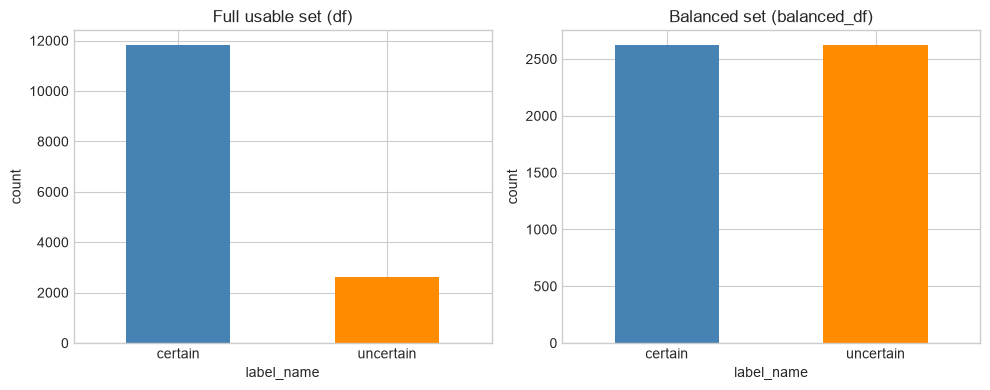

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["label_name"].value_counts().reindex(["certain", "uncertain"]).plot(
    kind="bar", ax=axes[0], color=["steelblue", "darkorange"], rot=0
)
axes[0].set_title("Full usable set (df)")
axes[0].set_xlabel("label_name")
axes[0].set_ylabel("count")

balanced_df["label_name"].value_counts().reindex(["certain", "uncertain"]).plot(
    kind="bar", ax=axes[1], color=["steelblue", "darkorange"], rot=0
)
axes[1].set_title("Balanced set (balanced_df)")
axes[1].set_xlabel("label_name")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

The left plot shows the natural imbalance after cleaning. The right plot is the undersampled probing set with equal class counts.

## Document type by label

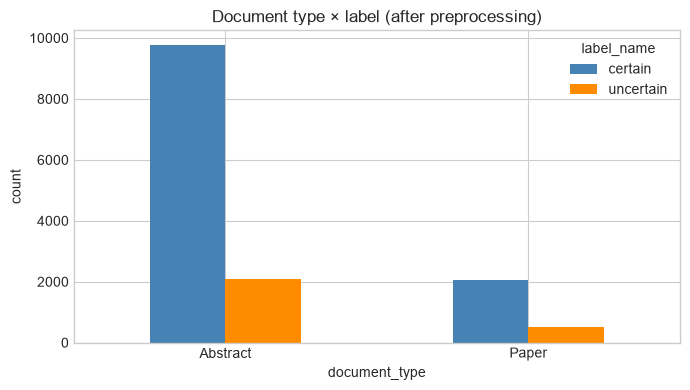

label_name,certain,uncertain
document_type,,
Abstract,9758,2101
Paper,2055,519


In [51]:
ct = pd.crosstab(df["document_type"], df["label_name"]).reindex(columns=["certain", "uncertain"])
ax = ct.plot(kind="bar", figsize=(7, 4), color=["steelblue", "darkorange"], rot=0)
ax.set_title("Document type × label (after preprocessing)")
ax.set_xlabel("document_type")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()
ct

## Sentence length by class

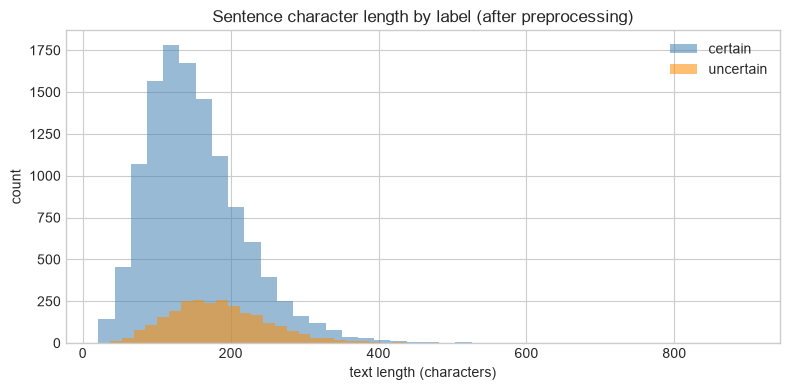

label_name,certain,uncertain
count,11813.000000,2620.000000
mean,152.308389,186.622901
std,67.815511,70.036311
min,21.000000,37.000000
25%,105.000000,137.000000
50%,142.000000,180.000000
75%,188.000000,227.000000
max,899.000000,674.000000


In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
df.loc[df["label_name"] == "certain", "text_len"].hist(
    bins=40, alpha=0.55, color="steelblue", label="certain", ax=ax
)
df.loc[df["label_name"] == "uncertain", "text_len"].hist(
    bins=40, alpha=0.55, color="darkorange", label="uncertain", ax=ax
)
ax.set_title("Sentence character length by label (after preprocessing)")
ax.set_xlabel("text length (characters)")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

df.groupby("label_name")["text_len"].describe().T

Interesting to note that on this dataset the certain sentences tend to be a little longer than uncertain ones. Probably because medical facts that are stated as factual tend to be a bit longer.

## Negation vs speculation overlap

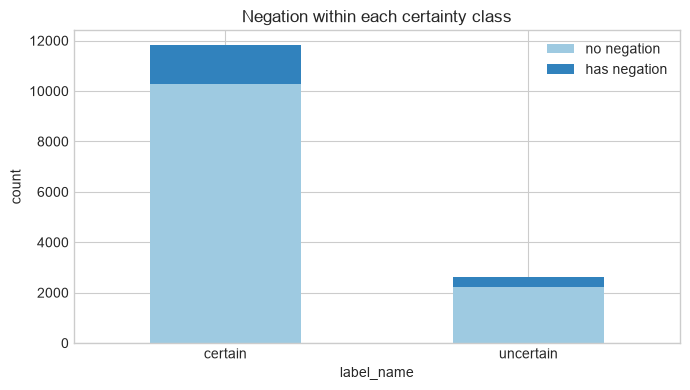

,no negation,has negation
label_name,,
certain,10278,1535
uncertain,2219,401


In [53]:
neg_ct = pd.crosstab(df["label_name"], df["has_negation"]).reindex(["certain", "uncertain"])
neg_ct.columns = ["no negation", "has negation"]
ax = neg_ct.plot(kind="bar", stacked=True, figsize=(7, 4), color=["#9ecae1", "#3182bd"], rot=0)
ax.set_title("Negation within each certainty class")
ax.set_xlabel("label_name")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()
neg_ct

### Has-negation statement examples

In [54]:
neg_df = df.loc[df["has_negation"]].head(5)
neg_df[["id", "text", "label_name", "has_negation", "speculation_cues"]]

,id,text,label_name,has_negation,speculation_cues
3,4,"PMA treatment, and not retinoic acid treatment of the U937 cells acts in inducing NF-KB expression in the nuclei.",certain,True,
5,6,"When U937 cells were infected with HIV-1, no induction of NF-KB factor was detected, whereas high level of progeny v...",uncertain,True,suggesting that this factor was not required for viral replication
9,10,"Tandem copies of this 67-bp MnlI-AluI fragment, when fused to the chloramphenicol acetyltransferase gene driven by t...",uncertain,True,Jurkat T cells or HeLa cells
12,13,"In agreement with the results of gel retardation assays, tandem copies of the E6 motif stimulated transcription in A...",uncertain,True,Jurkat or HeLa
14,15,"In striking contrast to the mouse Ig heavy-chain enhancer, in which the octamer motif acts as a B-cell-specific enha...",certain,True,


# Summary

- **Import** loads all BioScope sources as released, including medical `*` rows.
- **Exploration** shows medical notes are anonymised and unusable; abstracts/papers hold readable text and speculation annotations.
- **Preprocessing** drops medical rows and short fragments, maps speculation → certain/uncertain, balances classes, and saves CSVs.
- **Visualisation** confirms imbalance, source mix, length differences, and negation overlap on the cleaned tables.
- Next step (later): train / validation / test splitting and lexical-leakage controls.